# CNN Model v2

## Objective

This notebook trains a revised baseline CNN using the deduplicated modelling dataset produced in Step 3 v2.

The previous modelling workflow was based on the original 3,477 image records. Extended data-quality analysis subsequently identified substantial exact duplication and confirmed duplicate leakage across the original train, validation and test subsets.

The revised model therefore uses the leakage-controlled dataset of 2,407 usable unique images and the new stratified train/validation/test split. The objective is to establish a cleaner baseline whose evaluation better reflects performance on previously unseen image content.

## Reproducibility and configuration

A fixed random seed is used to make model initialisation, dataset shuffling and augmentation as reproducible as possible.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1789767920.871490   13538 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789767921.761590   13538 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789767924.482617   13538 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [8]:

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "GVLiD"
SPLIT_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_split.csv"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Raw data exists:", RAW_DATA_DIR.exists())
print("Split file exists:", SPLIT_PATH.exists())

Raw data exists: True
Split file exists: True


In [2]:
def find_project_root(start: Path) -> Path:
    """Find the repository root from either the project or notebooks folder."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "__init__.py").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not find the project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

tf.keras.utils.set_random_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Random seed:", RANDOM_SEED)

TensorFlow version: 2.21.0
Project root: /home/chetan/Desktop/DL_Project/grapevine-disease-classification
Random seed: 42


## Model configuration

The CNN uses 128 × 128 RGB images with a batch size of 32. The four target classes are encoded consistently throughout training and evaluation.

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

CLASS_NAMES = [
    "Black Rot",
    "Esca",
    "Healthy",
    "Leaf Blight",
]

NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_INDEX.items()
}

print("Number of classes:", NUM_CLASSES)
print("Class mapping:", CLASS_TO_INDEX)

Number of classes: 4
Class mapping: {'Black Rot': 0, 'Esca': 1, 'Healthy': 2, 'Leaf Blight': 3}


In [9]:
RAW_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "GVLiD"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Split file:", SPLIT_PATH)
print("Raw dataset:", RAW_DATA_DIR)
print("Results directory:", RESULTS_DIR)

print("\nSplit file exists:", SPLIT_PATH.exists())
print("Raw dataset exists:", RAW_DATA_DIR.exists())

Split file: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/processed/dataset_split.csv
Raw dataset: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/raw/GVLiD
Results directory: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results

Split file exists: True
Raw dataset exists: True


## Dataset loading

The fixed train, validation and test allocation created during the revised EDA is loaded from `dataset_split.csv`. The data is not split again during modelling.

In [10]:
split_df = pd.read_csv(SPLIT_PATH)

print("Dataset shape:", split_df.shape)

print("\nColumns:")
print(split_df.columns.tolist())

display(split_df.head())

Dataset shape: (2407, 5)

Columns:
['image_filename', 'sha256', 'Target_Class', 'Vineyard', 'Split']


,image_filename,sha256,Target_Class,Vineyard,Split
0,healthy267.jpg,7a89f052a9b5c4a77ef9b6130b5f84d65a7da8218d738b...,Healthy,Vineyard_3,Train
1,black rot677.jpg,74f16e0042eecbc2b3de8418089eb4a1fc7266ef9a85d9...,Black Rot,Vineyard_25,Train
2,leaf blight431.jpg,856203b686272c318b09533e5ed7c6535ef8a37688b2ca...,Leaf Blight,Vineyard_8,Train
3,healthy413.jpg,d1d02735cc5304ee6569bb7e8b1eff34dcc9c6fd97574c...,Healthy,Vineyard_2,Train
4,esca675.jpg,f2486b88ab87fbceaf327f7ae0ff24857e1a4d3d012004...,Esca,Vineyard_24,Train


In [11]:
print("Total records:", len(split_df))
print("Unique SHA-256 hashes:", split_df["sha256"].nunique())

print("\nImages per split:")
print(split_df["Split"].value_counts())

print("\nImages per class:")
print(split_df["Target_Class"].value_counts())

Total records: 2407
Unique SHA-256 hashes: 2407

Images per split:
Split
Train         1684
Test           362
Validation     361
Name: count, dtype: int64

Images per class:
Target_Class
Healthy        1093
Esca            886
Leaf Blight     331
Black Rot        97
Name: count, dtype: int64


In [12]:
class_split_table = pd.crosstab(
    split_df["Split"],
    split_df["Target_Class"]
)

class_split_table = class_split_table.reindex(
    columns=CLASS_NAMES
)

display(class_split_table)

Target_Class,Black Rot,Esca,Healthy,Leaf Blight
Split,,,,
Test,15,133,164,50
Train,68,620,765,231
Validation,14,133,164,50


In [13]:
CLASS_TO_FOLDER = {
    "Black Rot": "Black rot",
    "Esca": "esca",
    "Healthy": "healthy",
    "Leaf Blight": "leaf blight",
}

split_df["image_path"] = split_df.apply(
    lambda row: str(
        RAW_DATA_DIR
        / CLASS_TO_FOLDER[row["Target_Class"]]
        / row["image_filename"]
    ),
    axis=1
)

display(
    split_df[
        [
            "image_filename",
            "Target_Class",
            "Split",
            "image_path",
        ]
    ].head()
)

,image_filename,Target_Class,Split,image_path
0,healthy267.jpg,Healthy,Train,/home/chetan/Desktop/DL_Project/grapevine-dise...
1,black rot677.jpg,Black Rot,Train,/home/chetan/Desktop/DL_Project/grapevine-dise...
2,leaf blight431.jpg,Leaf Blight,Train,/home/chetan/Desktop/DL_Project/grapevine-dise...
3,healthy413.jpg,Healthy,Train,/home/chetan/Desktop/DL_Project/grapevine-dise...
4,esca675.jpg,Esca,Train,/home/chetan/Desktop/DL_Project/grapevine-dise...


In [14]:
split_df["file_exists"] = (
    split_df["image_path"]
    .apply(lambda path: Path(path).exists())
)

missing_images = split_df[
    ~split_df["file_exists"]
]

print("Missing modelling images:", len(missing_images))

if len(missing_images) > 0:
    display(
        missing_images[
            [
                "image_filename",
                "Target_Class",
                "image_path",
            ]
        ].head(20)
    )

Missing modelling images: 0


In [15]:
split_df["label"] = (
    split_df["Target_Class"]
    .map(CLASS_TO_INDEX)
)

assert split_df["label"].notna().all()

split_df["label"] = split_df["label"].astype(int)

display(
    split_df[
        ["Target_Class", "label"]
    ]
    .drop_duplicates()
    .sort_values("label")
)

,Target_Class,label
1,Black Rot,0
4,Esca,1
0,Healthy,2
2,Leaf Blight,3


In [16]:
train_df = (
    split_df[split_df["Split"] == "Train"]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    split_df[split_df["Split"] == "Validation"]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    split_df[split_df["Split"] == "Test"]
    .copy()
    .reset_index(drop=True)
)

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 1684
Validation: 361
Test: 362


## Class imbalance

The deduplicated training set is imbalanced, particularly for Black Rot. Class weights are therefore calculated from the training subset so that errors on minority classes contribute more strongly to the training loss.

In [17]:
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

total_samples = len(train_df)
num_classes = len(class_counts)

CLASS_WEIGHTS = {
    int(class_index): total_samples / (num_classes * count)
    for class_index, count in class_counts.items()
}

print("Training class counts:")
print(class_counts)

print("\nClass weights:")
for class_index, weight in CLASS_WEIGHTS.items():
    print(
        f"{class_index} - {INDEX_TO_CLASS[class_index]}: "
        f"{weight:.4f}"
    )

Training class counts:
label
0     68
1    620
2    765
3    231
Name: count, dtype: int64

Class weights:
0 - Black Rot: 6.1912
1 - Esca: 0.6790
2 - Healthy: 0.5503
3 - Leaf Blight: 1.8225


## Image preprocessing

Images are resized to 128 × 128 pixels, converted to RGB tensors and normalised to the [0, 1] range before being provided to the CNN.

In [18]:
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [19]:
def create_dataset(df, training=False):
    image_paths = df["image_path"].to_numpy()
    labels = df["label"].to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [20]:
train_ds = create_dataset(
    train_df,
    training=True
)

validation_ds = create_dataset(
    validation_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

E0000 00:00:1789768403.297610   13538 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [21]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print(
        "Pixel range:",
        float(tf.reduce_min(images)),
        "to",
        float(tf.reduce_max(images))
    )

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Pixel range: 0.0 to 1.0


## Data augmentation

Moderate geometric augmentation is applied only during training. Horizontal flips, small rotations and small zoom transformations increase the visual diversity of the training data while preserving the underlying disease class.

Validation and test images are not randomly augmented so that evaluation remains deterministic.

In [22]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),
        layers.RandomRotation(
            0.10,
            seed=RANDOM_SEED
        ),
        layers.RandomZoom(
            0.10,
            seed=RANDOM_SEED
        ),
    ],
    name="data_augmentation"
)

## Baseline CNN architecture

A conventional convolutional neural network is trained from scratch as the leakage-controlled baseline.

Three convolutional blocks progressively learn spatial image features, while MaxPooling reduces the spatial dimensions of the feature maps. Global average pooling and dropout are used before the final dense classification layers to reduce model complexity and help limit overfitting.

In [23]:
model = keras.Sequential(
    [
        layers.Input(
            shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        ),

        data_augmentation,

        layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            128,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.30),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(0.30),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        ),
    ],
    name="cnn_v2_baseline"
)

In [25]:
model.summary()

Model: "cnn_v2_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,764 (397.52 KB)

 Trainable params: 101,764 (397.52 KB)

 Non-trainable params: 0 (0.00 B)

## Model compilation

The CNN uses the Adam optimiser with sparse categorical cross-entropy loss. Sparse categorical cross-entropy is appropriate because the four target classes are represented as integer labels.

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training strategy

The model is trained using the fixed deduplicated training subset and monitored against the validation subset after each epoch.

Early stopping limits unnecessary training once validation loss stops improving. Learning-rate reduction lowers the learning rate when validation performance plateaus, while model checkpointing preserves the best-performing model.

In [25]:
BEST_MODEL_PATH = (
    RESULTS_DIR
    / "cnn_v2_best.keras"
)

FINAL_MODEL_PATH = (
    RESULTS_DIR
    / "cnn_v2_final.keras"
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [26]:
MAX_EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=MAX_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

Epoch 1/50


/home/chetan/miniforge3/envs/research/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1789768435.581215   15830 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.
W0000 00:00:1789768436.875733   15830 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.


 1/53 ━━━━━━━━━━━━━━━━━━━━ 4:10 5s/step - accuracy: 0.0938 - loss: 1.1092

W0000 00:00:1789768437.309882   15827 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.


 2/53 ━━━━━━━━━━━━━━━━━━━━ 45s 885ms/step - accuracy: 0.2656 - loss: 1.2461

W0000 00:00:1789768437.837907   15829 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.
W0000 00:00:1789768438.091664   15830 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.4400 - loss: 1.3333
Epoch 1: val_loss improved from None to 0.97825, saving model to /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_best.keras

Epoch 1: finished saving model to /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_best.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 902ms/step - accuracy: 0.4400 - loss: 1.3333 - val_accuracy: 0.5263 - val_loss: 0.9783 - learning_rate: 0.0010
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 912ms/step - accuracy: 0.4941 - loss: 1.1721
Epoch 2: val_loss improved from 0.97825 to 0.90404, saving model to /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_best.keras

Epoch 2: finished saving model to /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_best.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 981ms/step - accuracy: 0.4941 - loss: 1.1721 - val_accuracy: 0.5983 - val_loss: 0.9040 - learning_r

In [27]:
model.save(FINAL_MODEL_PATH)

print("Final model saved to:", FINAL_MODEL_PATH)

Final model saved to: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_final.keras


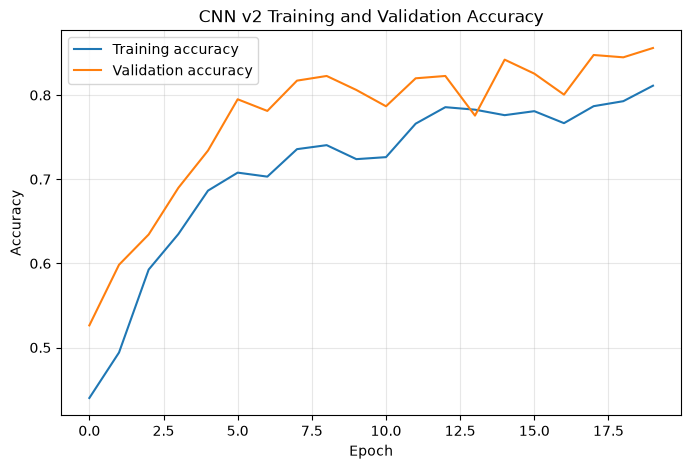

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN v2 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

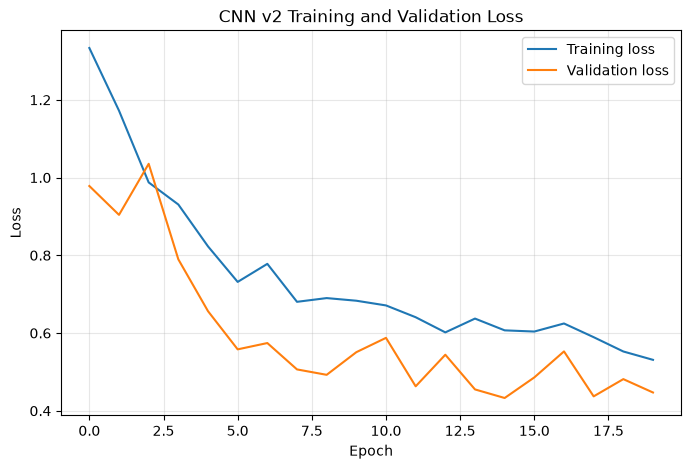

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN v2 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [30]:
best_epoch = (
    np.argmin(history.history["val_loss"]) + 1
)

best_val_loss = min(
    history.history["val_loss"]
)

best_val_accuracy = history.history[
    "val_accuracy"
][best_epoch - 1]

print("Best epoch:", best_epoch)
print(f"Best validation loss: {best_val_loss:.4f}")
print(
    f"Validation accuracy at best epoch: "
    f"{best_val_accuracy:.4f}"
)

Best epoch: 15
Best validation loss: 0.4329
Validation accuracy at best epoch: 0.8421


## Conclusion

A new baseline CNN was successfully trained using the deduplicated and leakage-controlled dataset produced during the revised EDA. The fixed train, validation and test allocation from `dataset_split.csv` was preserved throughout modelling, ensuring that the model was trained on 1,684 unique training images without redefining the dataset split.

The CNN retained a conventional architecture with three convolutional blocks, MaxPooling, global average pooling, dropout and a four-class softmax output. Moderate geometric augmentation was applied only to the training data, while class weights were introduced to reduce the impact of the strong class imbalance identified after deduplication, particularly for the underrepresented Black Rot class.

Training was controlled using early stopping, learning-rate reduction and model checkpointing. Training stopped automatically after validation performance stopped improving, and the best-performing weights were restored. The best validation performance occurred around epoch 15, with a validation loss of approximately 0.43 and validation accuracy above 80%.

These results suggest that the CNN learned useful visual patterns from the revised dataset without clear evidence of severe overfitting during training. However, validation accuracy alone is not sufficient to assess model quality because of the remaining class imbalance.

The saved best model will therefore be evaluated separately on the untouched test subset in the evaluation notebook, using class-level metrics such as precision, recall, F1-score and the confusion matrix.